In [ ]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np

from model.loss_function.siamese.custom_siamese_loss import CustomSiameseLoss
from model.architecture.siamese_residual_block import ResidualSiameseModel
from data_augmentation.matrices_loader import MatricesLoader
from model.trainers.siamese_trainer import SiameseTrainer
from utils.io_utils import *
from analytic_methods.EVM_method import EVM
from visualization.results.metrics_visualizator import MetricsVisualizator
from visualization.data.weights_visualizator import WeightsVisualizator
from metrics.evaluator import Evaluator
from model.loss_function.siamese.COP_optimized_siamese_loss import COPOptimizedSiameseLoss

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device used: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device used: cuda
GPU: NVIDIA GeForce RTX 2060


In [3]:
IS_UNIFORM = True
CRITERIA_NUM = 5
CONSISTENCY_RATES = [0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.08, 0.1, 0.12, 0.14, 0.15, 
                     0.17, 0.18, 0.2, 0.23, 0.27, 0.3, 0.33, 0.37, 0.4, 0.45, 0.5]
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000

BATCH_SIZE = 1024
LEARNING_RATE = 5e-4

In [4]:
def compare_results_batch(solver, evaluator, matrices, weights, predicted_priority_weights, nn_name):
    all_mae_evm = []
    all_kendall_taus_evm = []

    all_mae_nn= []
    all_kendall_taus_nn = []

    for test_matrices, weights_vectors, pred_weights_vectors in zip(matrices.values(), weights.values(), predicted_priority_weights.values()):
        evm_weights_vectors, _ = solver.compute_batch(test_matrices)
        mae_evm, kendall_taus_evm = evaluator.evaluate_batch(weights_vectors, evm_weights_vectors)
        mae_nn, kendal_taus_nn = evaluator.evaluate_batch(weights_vectors, pred_weights_vectors)

        all_mae_evm.append(np.mean(mae_evm))
        all_kendall_taus_evm.append(np.mean(kendall_taus_evm))
        all_mae_nn.append(np.mean(mae_nn))
        all_kendall_taus_nn.append(np.mean(kendal_taus_nn))

    final_mae_evm = np.array(all_mae_evm)
    final_kendall_taus_evm = np.array(all_kendall_taus_evm)
    final_mae_nn = np.array(all_mae_nn)
    final_kendal_taus_nn = np.array(all_kendall_taus_nn)

    print("\n--- GLOBAL EXPERIMENT RESULTS ---")
    print(f"Analyzed a total of {len(CONSISTENCY_RATES)} consistency rates.")
    print(f"Global mean CR: {np.mean(CONSISTENCY_RATES):.4f}")
    print(f"Global mean MAE (EVM): {np.mean(final_mae_evm):.4f}, NN: {np.mean(final_mae_nn):.4f}")
    print(f"Global mean Kendall correlation (EVM): {np.mean(final_kendall_taus_evm):.4f}, NN: {np.mean(final_kendal_taus_nn):.4f}")

    viz = MetricsVisualizator()
    viz.plot_comparison(CONSISTENCY_RATES, final_mae_evm, final_kendall_taus_evm, final_mae_nn, final_kendal_taus_nn, nn_name)

## Searching for best loss weights

## Optimizing loss function parts

## Increasing training data quantity

## Opposite Crs

In [10]:
loader = MatricesLoader()
train_dataset = load_train_dataset_siamese_wtih_opposite_cr(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese_with_opposite_cr(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr015, number of criteri

In [ ]:
COP = 1
REC = 2
STAB = 0.2
CONS = 0.5
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_opposite_crs"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = CustomSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.279154 | Valid Loss: 0.276599 | Valid MAE: 0.0428
Epoch number [20/500] | Train Loss: 0.278108 | Valid Loss: 0.276530 | Valid MAE: 0.0430
Epoch number 29: Learning Rate was reduced to 0.000250
Epoch number [30/500] | Train Loss: 0.277035 | Valid Loss: 0.275992 | Valid MAE: 0.0430
Epoch number 35: Learning Rate was reduced to 0.000125

EARLY STOPPING in epoch 38.
Wages are restored to the best valid loss: 0.275890
History and model: advanced_10000m_5crit_COP_optimized_opposite_crs was saved in models/siamese/cop100_rec200_stab20_cons50


In [12]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr015, number of criterias: 5).
Succ


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0429
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6407


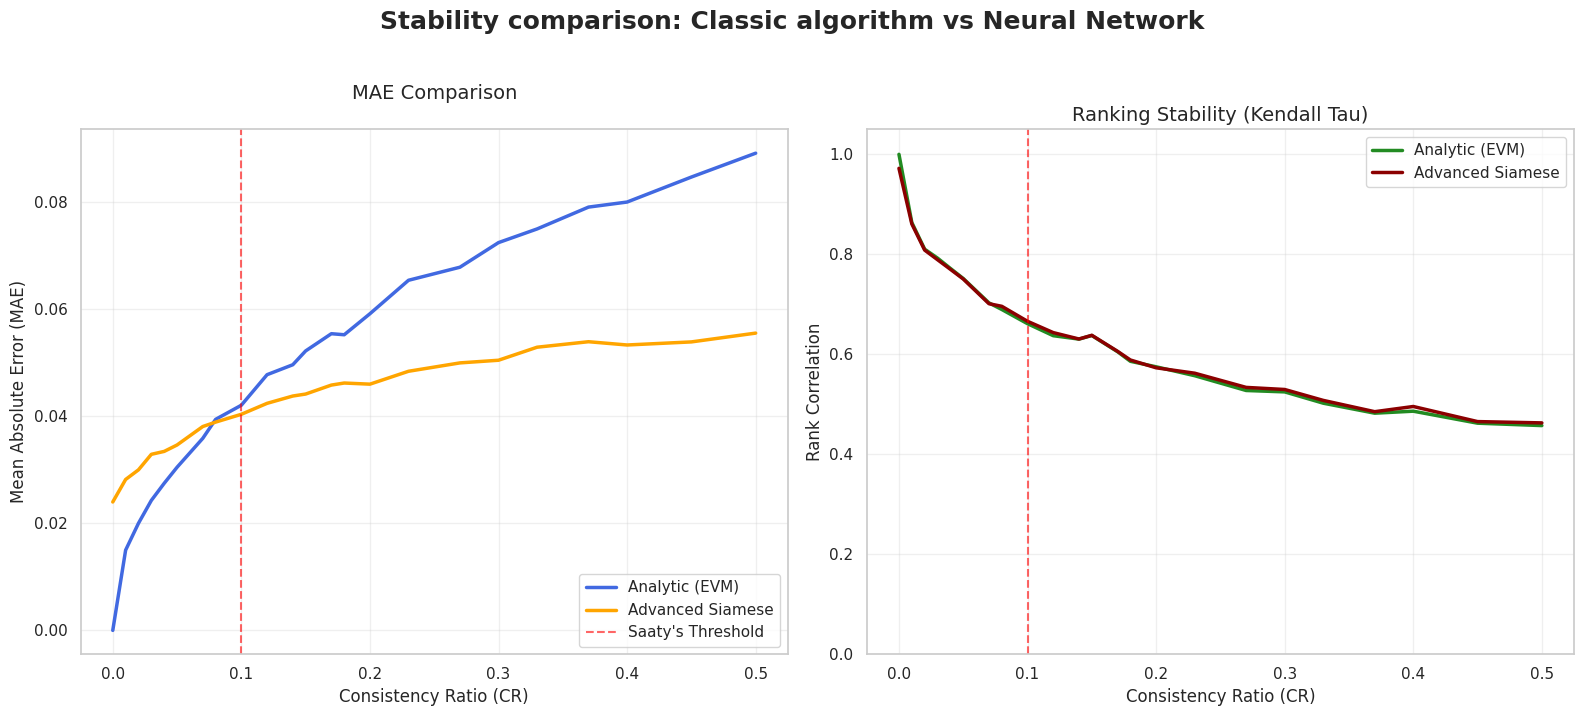

In [13]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

### Oposite Cr - Wnioski

Założeniem eksperymentu "Opposite CR" było zmuszenie sieci syjamskiej do nauki idealnej, niewrażliwej na szum reprezentacji poprzez jednoczesne podawanie do jej dwóch gałęzi macierzy o skrajnie różnym poziomie spójności (np. $CR \approx 0.01$ oraz $CR \approx 0.50$), które odpowiadały tym samym docelowym wektorom priorytetów. 

Podejście to nie przyniosło jednak poprawy wyników. Z matematycznego punktu widzenia, porażka tego podejścia wynika z trzech kluczowych mechanizmów:

#### 1. Konflikt gradientów na wagach współdzielonych
Fundamentem sieci syjamskiej jest współdzielenie wag między obiema gałęziami ekstraktora cech. W scenariuszu "Opposite CR", algorytm wstecznej propagacji napotyka na destrukcyjny konflikt:
* **Gałąź czysta ($CR \approx 0$):** Generuje precyzyjne, małe gradienty, które starają się delikatnie dostroić wagi do wyłapywania subtelnych zależności matematycznych w idealnej macierzy.
* **Gałąź zaszumiona ($CR \approx 0.5$):** Z powodu ogromnego błędu rekonstrukcji, generuje potężne, chaotyczne gradienty.
Ponieważ wagi są aktualizowane na podstawie sumy błędów z obu gałęzi, **chaotyczny gradient z zaszumionej macierzy całkowicie nadpisuje i niszczy precyzyjne dostrajanie z czystej macierzy**. W efekcie sieć zapomina, jak poprawnie rozwiązywać łatwe przykłady.

#### 2. Zapaść reprezentacji ukrytej
Sieć neuronowa zawsze dąży do znalezienia najtańszego energetycznie (matematycznie) punktu w krajobrazie funkcji straty. Zmuszenie jednej sieci do zmapowania ekstremalnie różnych wejść (idealnego porządku i niemal całkowitego chaosu) na dokładnie ten sam punkt wyjściowy wymusza na niej pójście na kompromis.
Sieć przestaje analizować faktyczną strukturę macierzy (bo reguły działające dla gałęzi A są karane w gałęzi B) i zaczyna stosować **regresję do średniej**. Zwraca "bezpieczne", płaskie wektory wag, które nie generują gigantycznych kar dla macierzy zaszumionych, ale jednocześnie drastycznie obniżają dokładność (Kendall Tau) dla macierzy idealnych. Zjawisko to potocznie nazywa się "zapaścią reprezentacji".

#### 3. Naruszenie założeń topologicznych rozmaitości (Manifold Hypothesis)
Architektury syjamskie (często wykorzystujące *Contrastive Loss* lub uczące się reprezentacji ukrytych) opierają się na założeniu, że niewielka zmiana na wejściu (dodanie lekkiego szumu) powinna skutkować równie niewielką zmianą w przestrzeni ukrytej (Latent Space). 
Parowanie macierzy idealnej z macierzą całkowicie zniekształconą łamie to założenie. Z punktu widzenia topologii, te dwie macierze leżą w zupełnie innych rejonach przestrzeni wejściowej. Wymuszanie na sieci, by traktowała je jako matematycznie identyczne poprzez te same wagi, uniemożliwia wykształcenie gładkiej, spójnej funkcji mapującej.

#### Podsumowanie
Podejście "Opposite CR" udowodniło, że **ekstremalna augmentacja danych nie zawsze działa jako regularyzator**. W architekturach ze współdzielonymi wagami, podawanie skrajnych przeciwieństw w jednym kroku uczącym tworzy sprzeczne sygnały optymalizacyjne. Aby uodpornić model na szum bez niszczenia jego precyzji, znacznie skuteczniejsze okazało się stopniowe zwiększanie zaszumienia lub stosowanie mechanizmów atencji (jak w sieci GAT), zamiast brutalnego parowania skrajności w architekturze syjamskiej.

## Siamese Neural Network

In [6]:
loader = MatricesLoader()
CRITERIA_NUM = 5
train_dataset = load_train_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 10000 noised matrices (level: cr015, number of criteri

In [ ]:
COP = 0.2
REC = 10
STAB = 2.5
CONS = 4
CRITERIA_NUM = 5
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = COPOptimizedSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.159645 | Valid Loss: 0.158920 | Valid MAE: 0.0629
Epoch number 16: Learning Rate was reduced to 0.000250
Epoch number [20/500] | Train Loss: 0.159463 | Valid Loss: 0.158940 | Valid MAE: 0.0631
Epoch number 30: Learning Rate was reduced to 0.000125
Epoch number [30/500] | Train Loss: 0.159407 | Valid Loss: 0.158908 | Valid MAE: 0.0629
Epoch number 36: Learning Rate was reduced to 0.000063
Epoch number [40/500] | Train Loss: 0.159323 | Valid Loss: 0.158876 | Valid MAE: 0.0630
Epoch number 43: Learning Rate was reduced to 0.000031
Epoch number 49: Learning Rate was reduced to 0.000016
Epoch number [50/500] | Train Loss: 0.159281 | Valid Loss: 0.158824 | Valid MAE: 0.0629

EARLY STOPPING in epoch 52.
Wages are restored to the best valid loss: 0.158782
History and model: advanced_10000m_5crit_COP_optimized was saved in models/siamese/cop20_rec1000_stab250_cons400


In [8]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr014, number of criterias: 5).
Successfully uploaded 1000 noised matrices (level: cr015, number of criterias: 5).
Succ


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0508, NN: 0.0629
Global mean Kendall correlation (EVM): 0.6398, NN: 0.6425


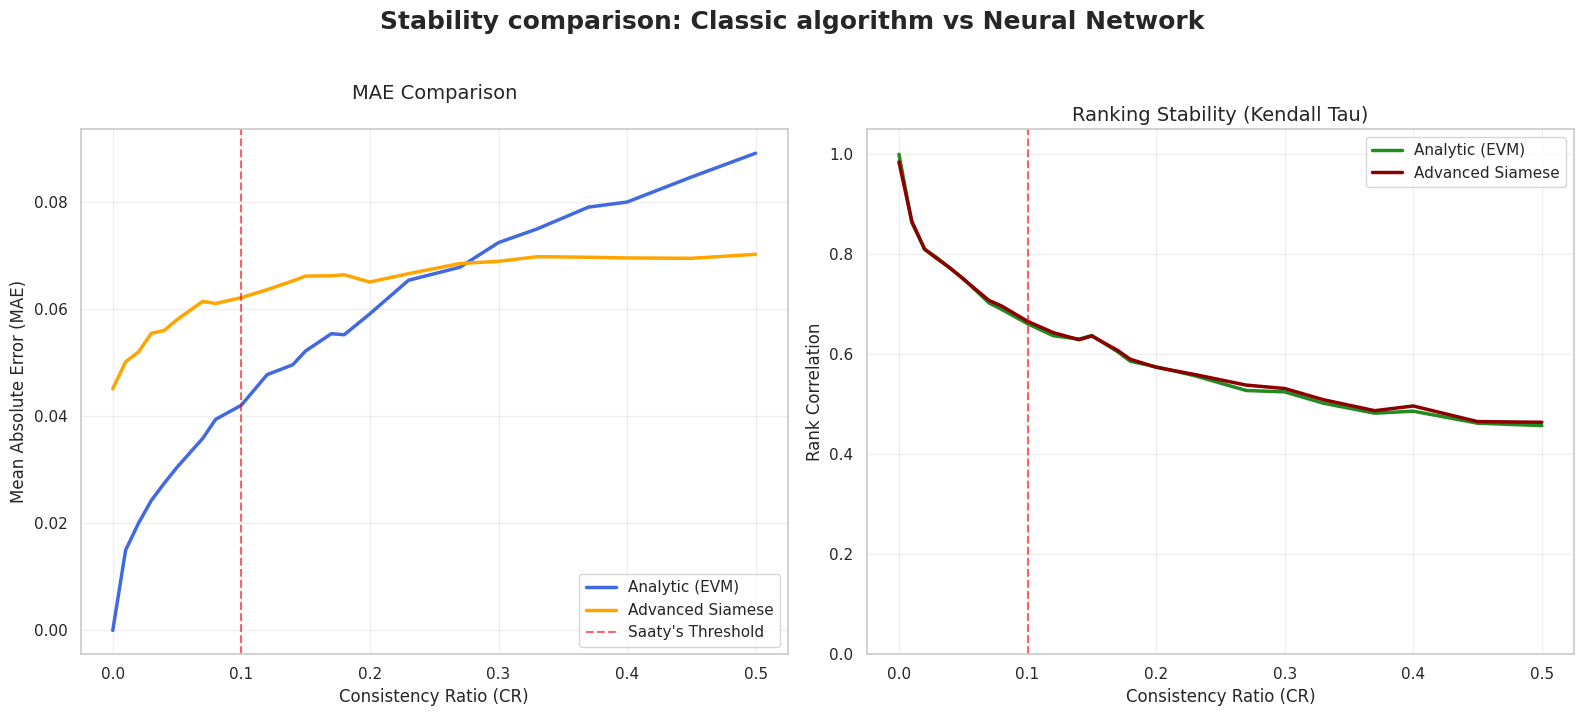

In [9]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

Analiza wykresów wyraźnie wskazuje, że obecna konfiguracja wag wielokryterialnej funkcji straty (COP = 0.2, REC = 10, STAB = 2.5, CONS = 4) jest nieodpowiednia i wprost hamuje potencjał sieci syjamskiej. Ze względu na drastyczną dominację członu rekonstrukcyjnego nad członem zachowania kolejności - COP, model podczas wstecznej propagacji błędu marginalizuje topologię rankingu, skupiając się niemal wyłącznie na dopasowywaniu odległości liczbowych. Silne wagi regularyzacyjne dla spójności i stabilności (CONS i STAB) ściągają wagi modelu w stronę bezpiecznego uśredniania, co tłumaczy bardzo wysoki, nienaturalny błąd bazowy dla macierzy idealnie spójnych. Aby sieć przestała być tylko drogim aproksymatorem EVM i zaczęła wygrywać w zadaniu poprawnego szeregowania kryteriów, należy radykalnie odwrócić te proporcje, drastycznie zwiększając wagę COP kosztem REC, zmuszając tym samym architekturę do priorytetyzowania bezwzględnej kolejności logitów nad ich idealną wartością punktową.

## Experiments with different number of criteria

### Criteria 3

In [ ]:
TRAIN_MATRICES_NUM = 10000
VALID_MATRICES_NUM = 1000
TEST_MATRICES_NUM = 1000
CRITERIA_NUM = 3

loader = MatricesLoader()
train_dataset = load_train_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

In [ ]:
COP = 1
REC = 2
STAB = 0.2
CONS = 0.5
CRITERIA_NUM = 3
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = COPOptimizedSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

In [ ]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

In [ ]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

### Criteria 5

### Criteria 7

In [14]:
loader = MatricesLoader()
CRITERIA_NUM = 7
train_dataset = load_train_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 10000 noised matrices (level: cr000, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr001, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr002, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr003, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr004, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr005, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr007, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr008, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr010, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr012, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr014, number of criterias: 7).
Successfully uploaded 10000 noised matrices (level: cr015, number of criteri

In [ ]:
COP = 1
REC = 2
STAB = 0.2
CONS = 0.5
CRITERIA_NUM = 7
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = COPOptimizedSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.244307 | Valid Loss: 0.239541 | Valid MAE: 0.0272
Epoch number [20/500] | Train Loss: 0.242116 | Valid Loss: 0.238321 | Valid MAE: 0.0273
Epoch number [30/500] | Train Loss: 0.241122 | Valid Loss: 0.237814 | Valid MAE: 0.0274
Epoch number 40: Learning Rate was reduced to 0.000250
Epoch number [40/500] | Train Loss: 0.240462 | Valid Loss: 0.238040 | Valid MAE: 0.0274
Epoch number [50/500] | Train Loss: 0.239441 | Valid Loss: 0.237798 | Valid MAE: 0.0275
Epoch number 52: Learning Rate was reduced to 0.000125
Epoch number 58: Learning Rate was reduced to 0.000063
Epoch number [60/500] | Train Loss: 0.238639 | Valid Loss: 0.237705 | Valid MAE: 0.0274

EARLY STOPPING in epoch 61.
Wages are restored to the best valid loss: 0.237509
History and model: advanced_10000m_7crit_COP_optimized was saved in models/siamese/cop100_rec200_stab20_cons50


In [16]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 1000 noised matrices (level: cr000, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr001, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr002, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr003, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr004, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr005, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr007, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr008, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr010, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr012, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr014, number of criterias: 7).
Successfully uploaded 1000 noised matrices (level: cr015, number of criterias: 7).
Succ

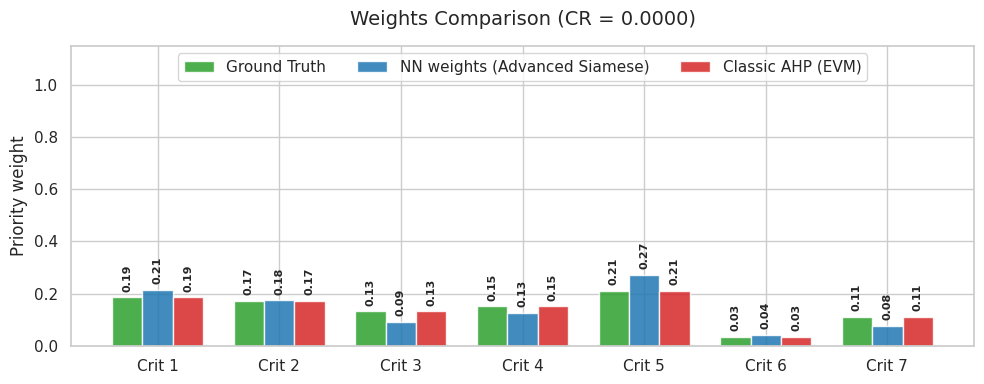

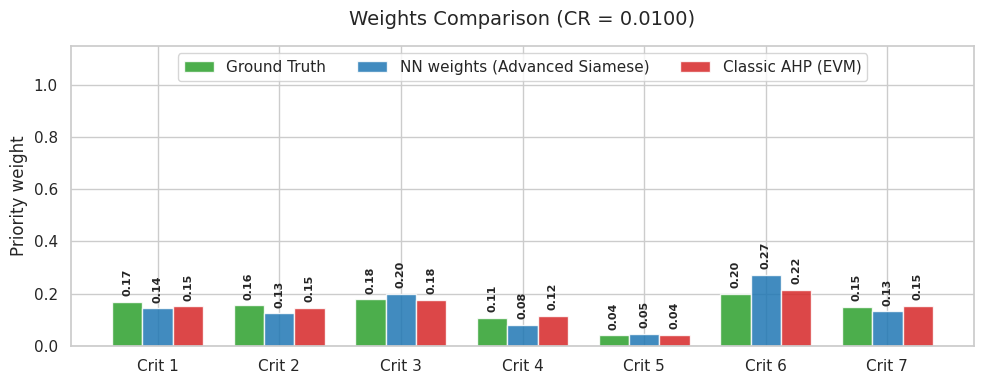

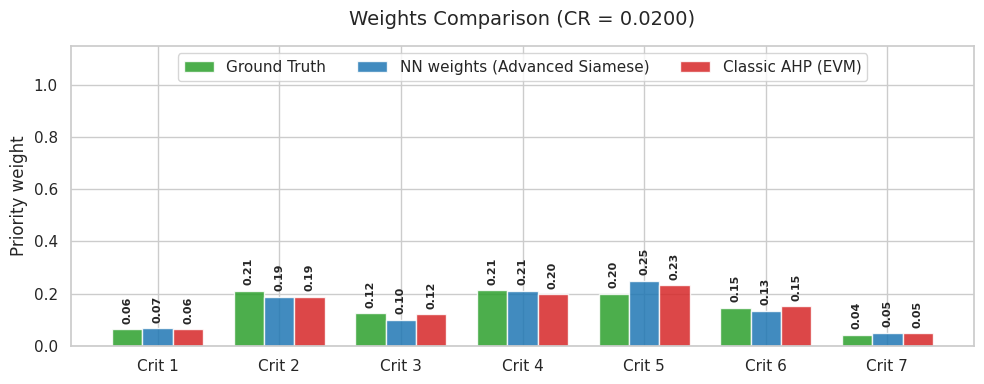

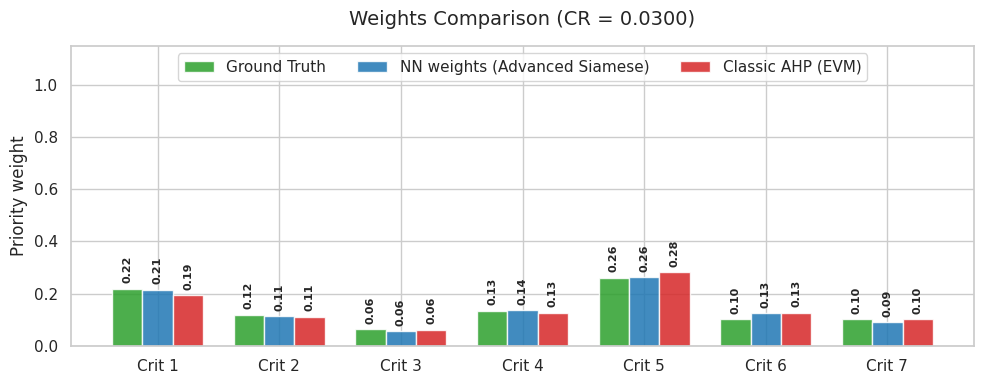

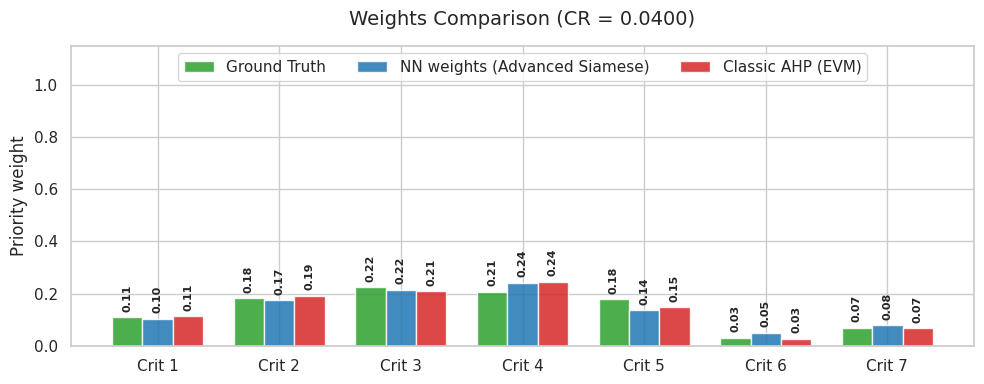

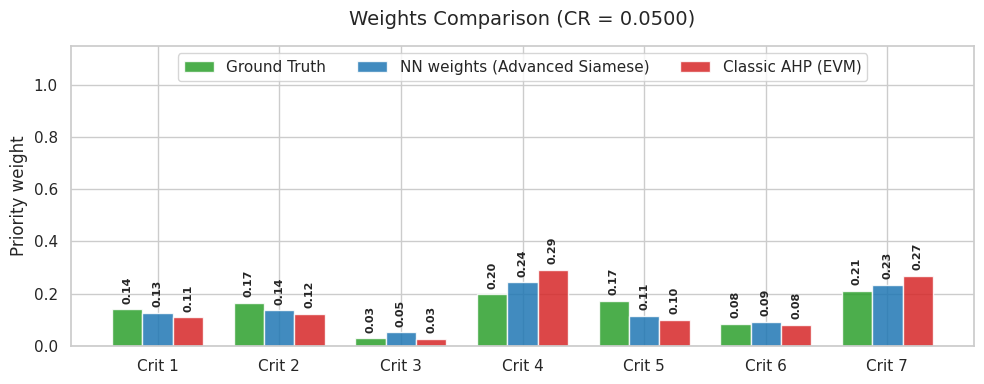

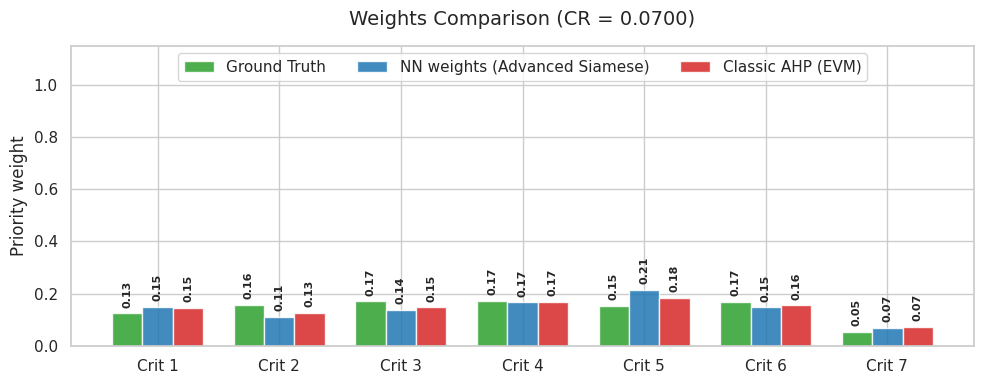

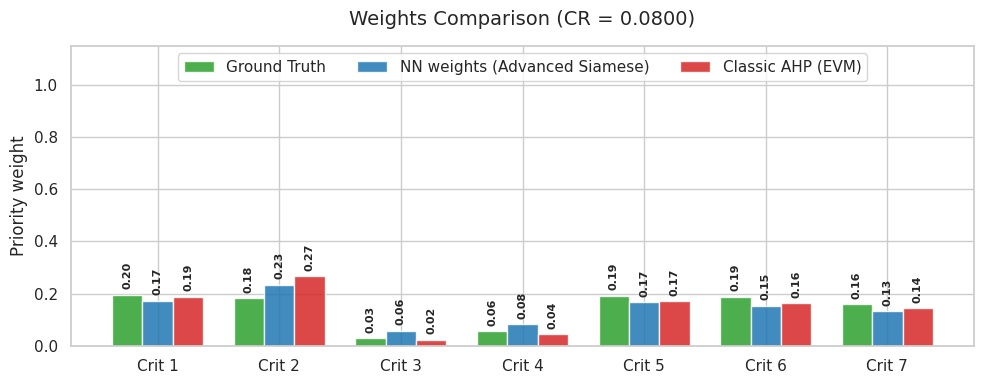

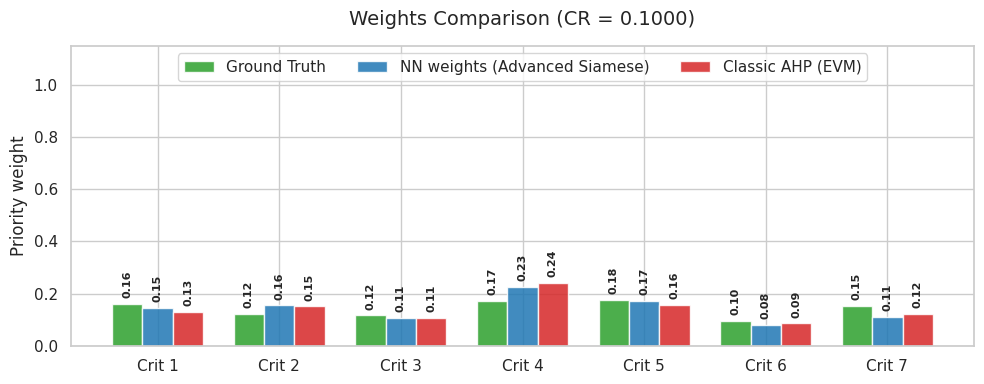

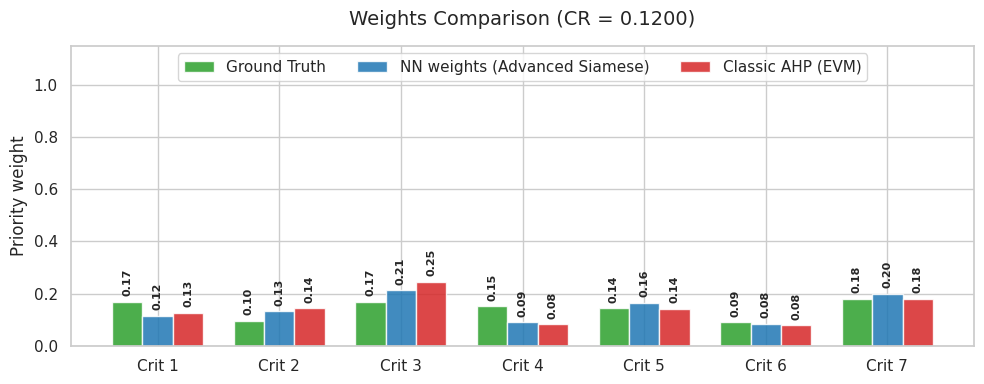

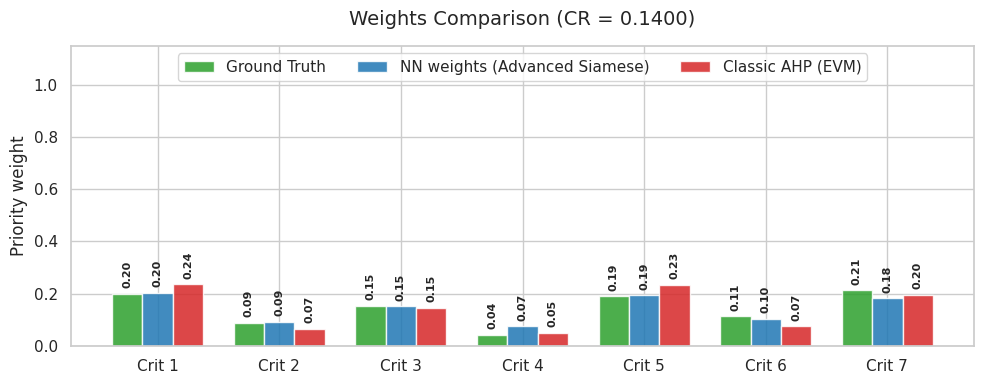

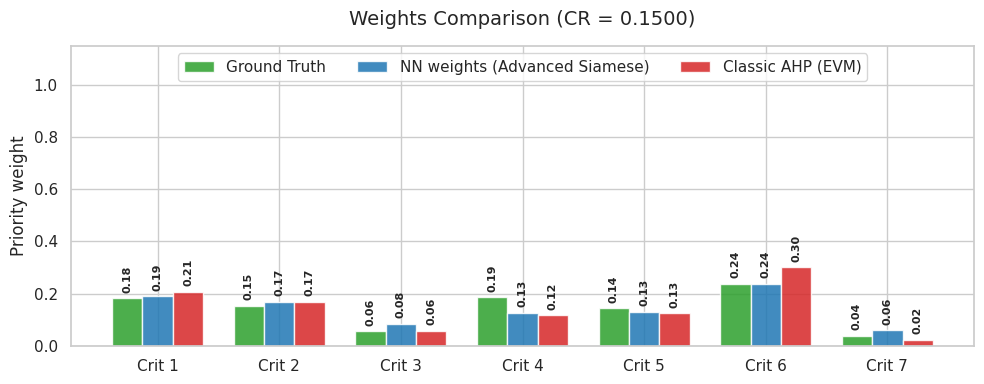

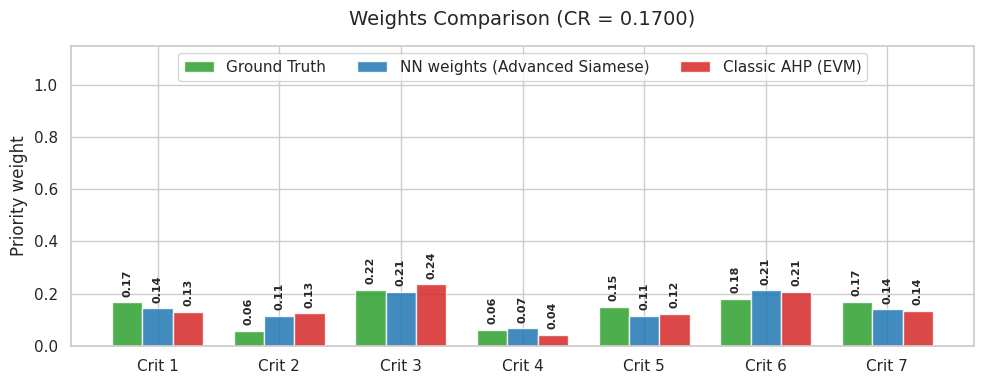

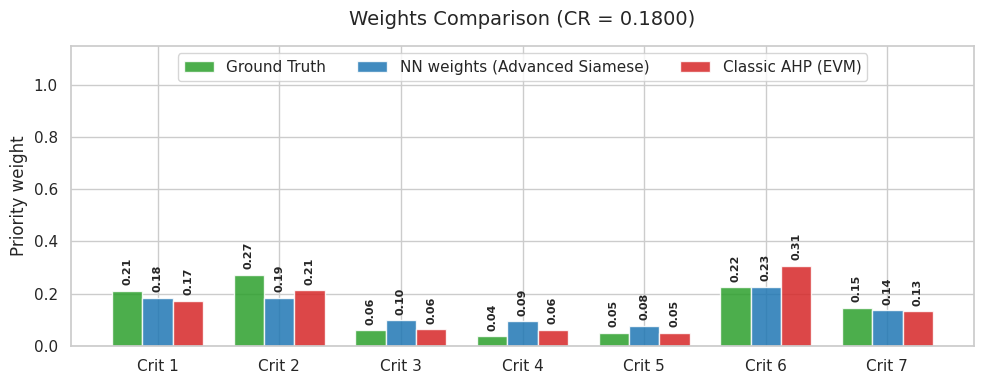

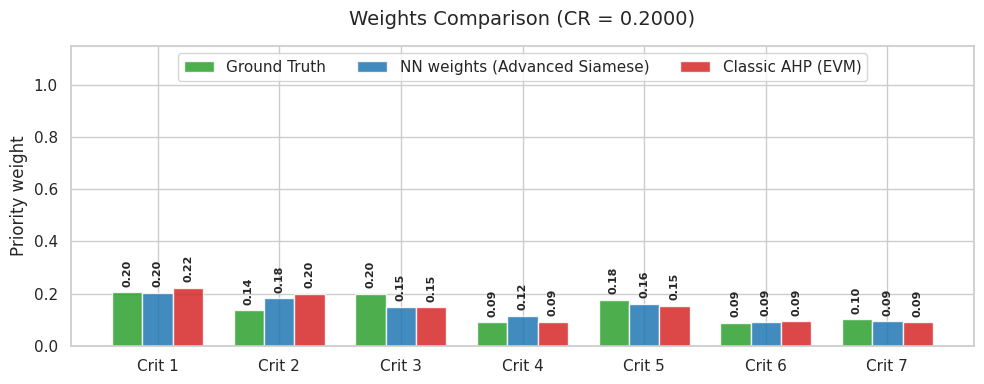

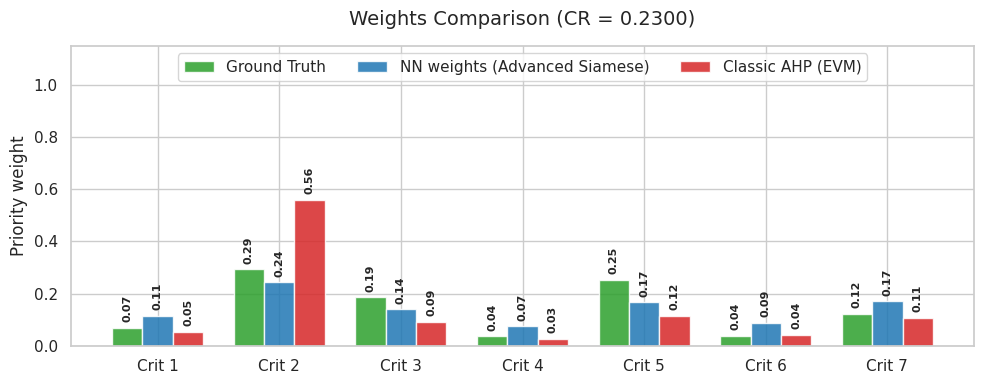

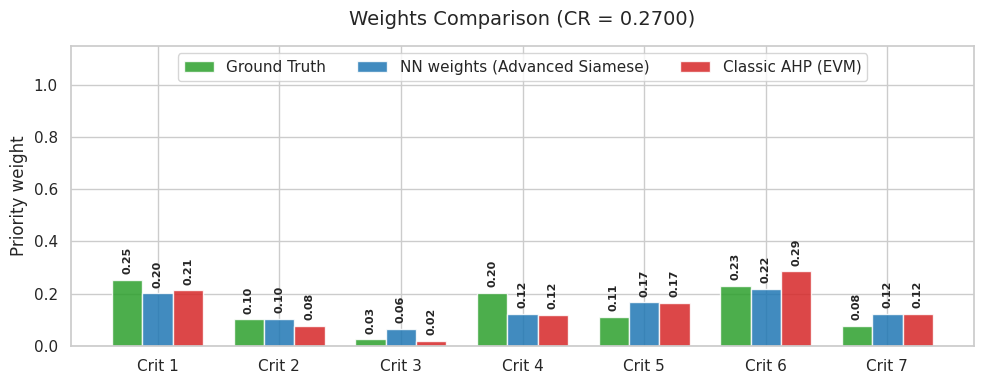

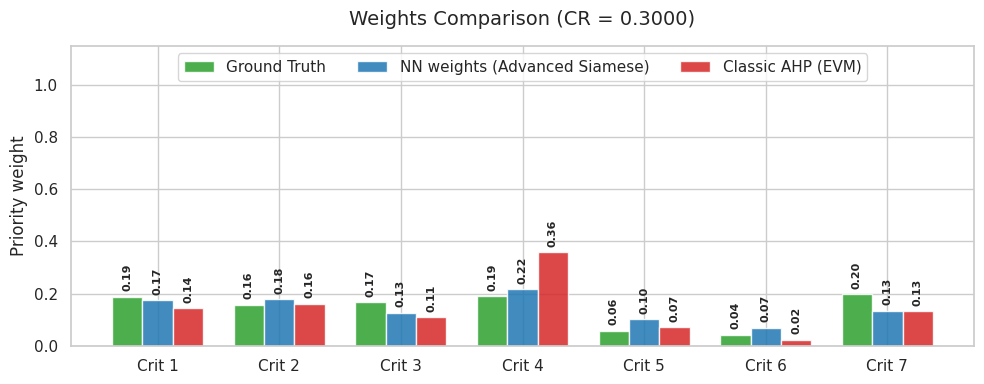

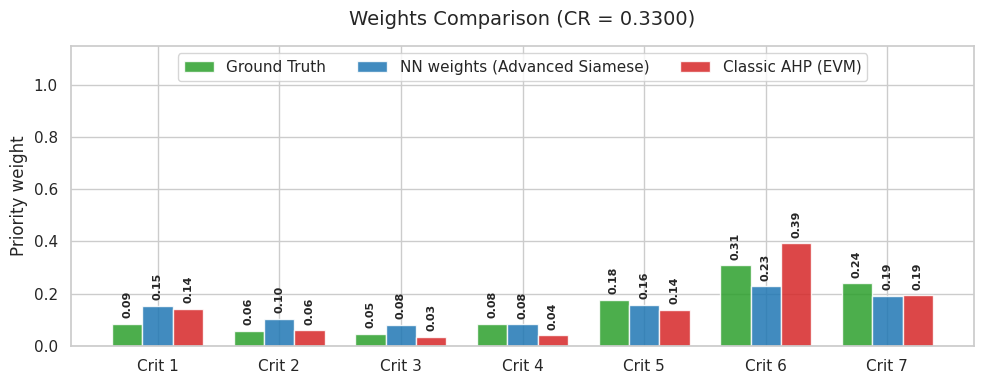

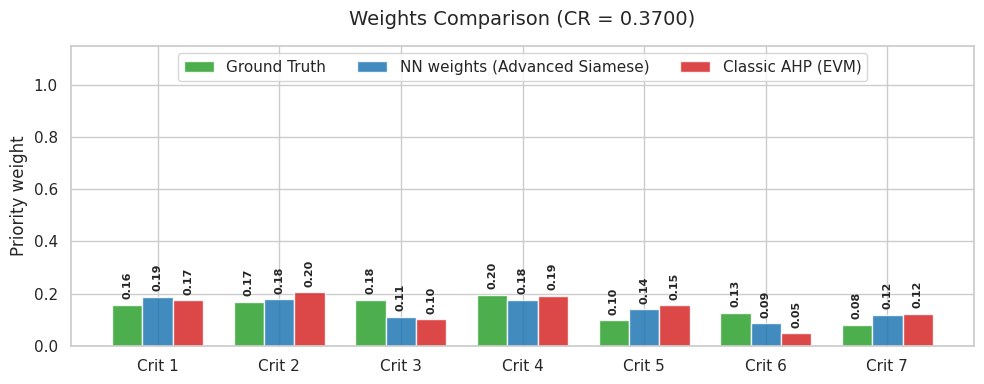

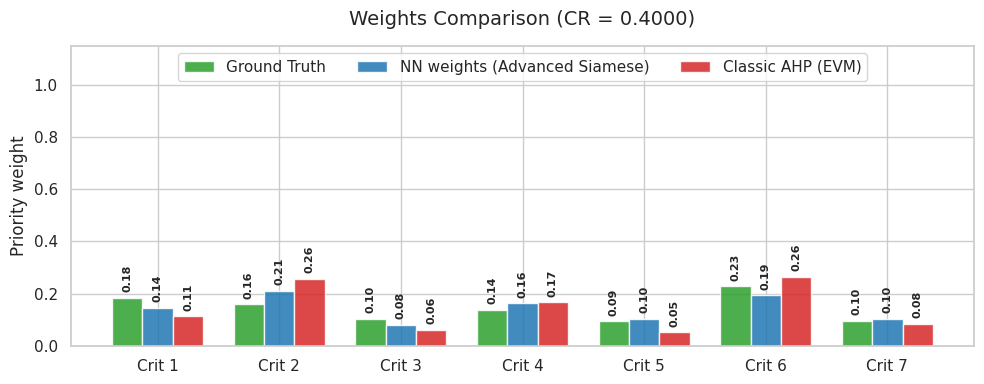

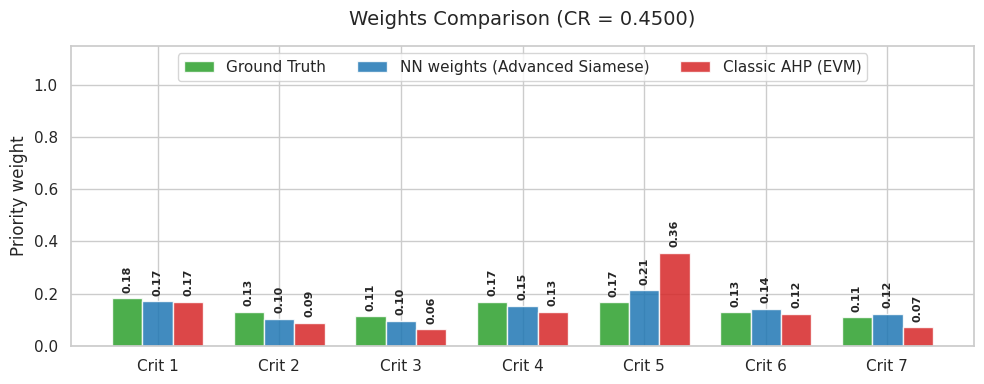

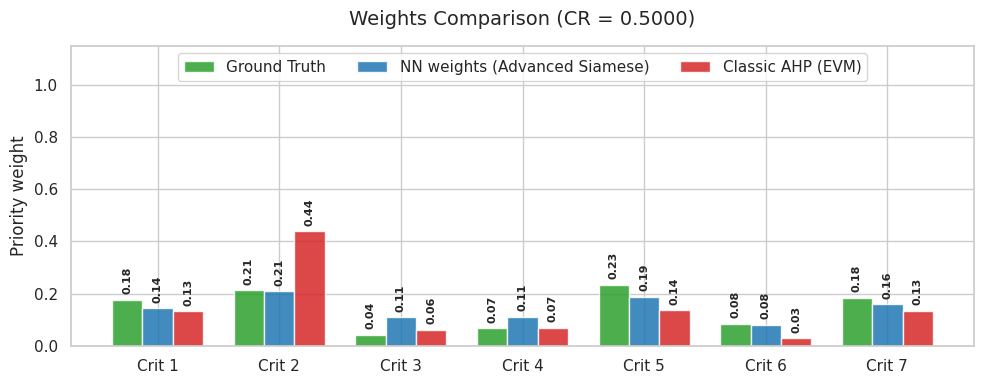

In [17]:
weights_visualizator = WeightsVisualizator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

for cr_key in weights.keys():
    pred_weights_vector = predicted_priority_weights.get(cr_key)[0]
    evm_weights_vector = evm_priority_weights.get(cr_key)[0].flatten()
    weights_vector = weights.get(cr_key)[0].flatten()

    weights_visualizator.plot_comparison_all(weights_vector, pred_weights_vector, evm_weights_vector, cr_key, nn_name)


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0302, NN: 0.0273
Global mean Kendall correlation (EVM): 0.6956, NN: 0.7028


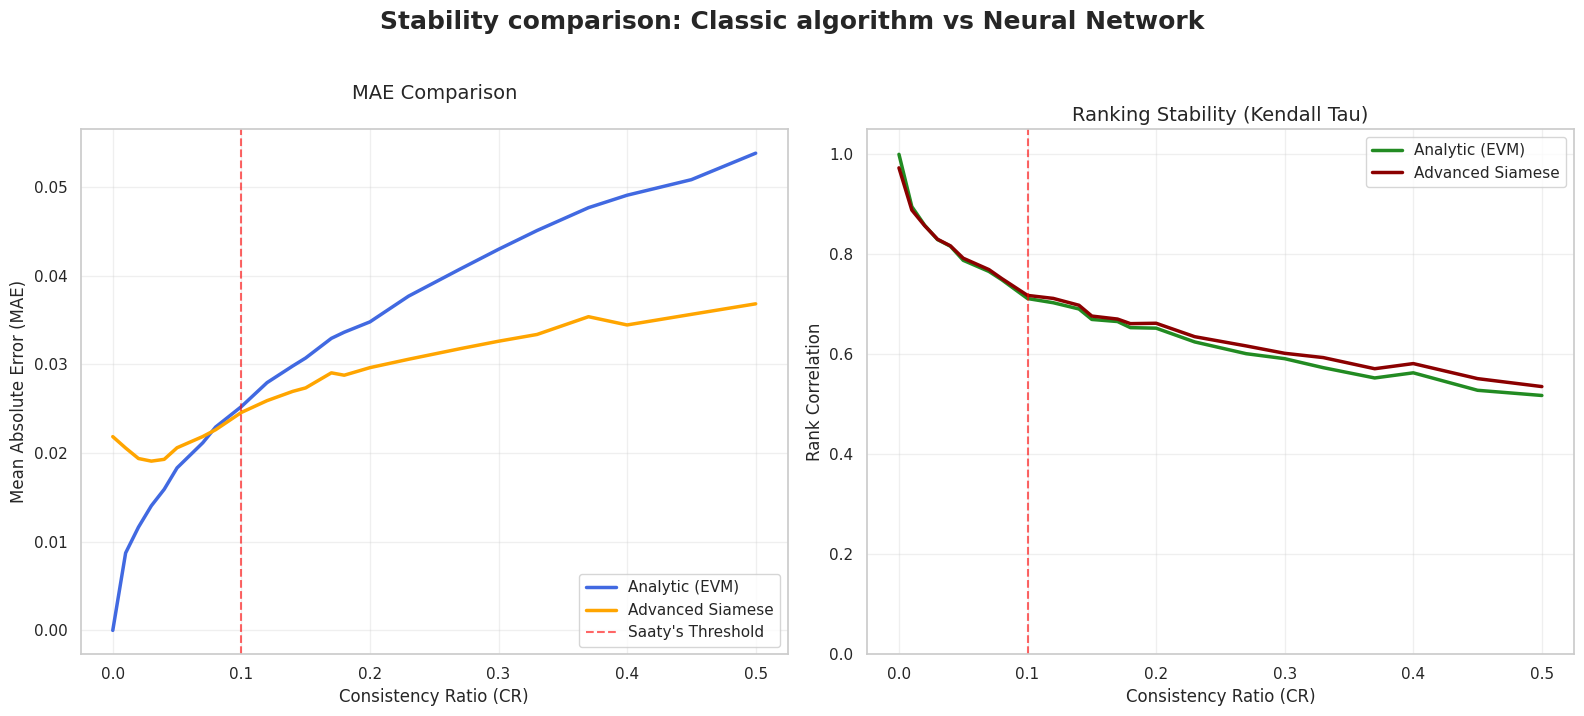

In [18]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)

### Criteria 9

In [20]:
loader = MatricesLoader()
CRITERIA_NUM = 9
train_dataset = load_train_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, TRAIN_MATRICES_NUM, IS_UNIFORM)
valid_dataset = load_valid_dataset_siamese(loader, CONSISTENCY_RATES, CRITERIA_NUM, VALID_MATRICES_NUM, IS_UNIFORM)

Successfully uploaded 20000 noised matrices (level: cr000, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr001, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr002, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr003, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr004, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr005, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr007, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr008, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr010, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr012, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr014, number of criterias: 9).
Successfully uploaded 20000 noised matrices (level: cr015, number of criteri

In [ ]:
COP = 1
REC = 2
STAB = 0.2
CONS = 0.5
CRITERIA_NUM = 9
MODEL_TYPE = "siamese"
MODEL_NAME = f"advanced_{TRAIN_MATRICES_NUM}m_{CRITERIA_NUM}crit_COP_optimized"

model = ResidualSiameseModel(n_criteria=CRITERIA_NUM)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = COPOptimizedSiameseLoss(COP, REC, STAB, CONS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
trainer = SiameseTrainer(model, optimizer, criterion, device)
model, history = trainer.train(train_dataloader, valid_dataloader, epochs=500)
trainer.save_state(MODEL_NAME)

Epoch number [10/500] | Train Loss: 0.231053 | Valid Loss: 0.224585 | Valid MAE: 0.0194
Epoch number [20/500] | Train Loss: 0.229035 | Valid Loss: 0.223207 | Valid MAE: 0.0194
Epoch number [30/500] | Train Loss: 0.228292 | Valid Loss: 0.222658 | Valid MAE: 0.0195
Epoch number [40/500] | Train Loss: 0.227854 | Valid Loss: 0.222606 | Valid MAE: 0.0196
Epoch number 44: Learning Rate was reduced to 0.000250
Epoch number [50/500] | Train Loss: 0.227307 | Valid Loss: 0.222125 | Valid MAE: 0.0196
Epoch number 52: Learning Rate was reduced to 0.000125
Epoch number 60: Learning Rate was reduced to 0.000063
Epoch number [60/500] | Train Loss: 0.226988 | Valid Loss: 0.221979 | Valid MAE: 0.0196
Epoch number 68: Learning Rate was reduced to 0.000031
Epoch number [70/500] | Train Loss: 0.226817 | Valid Loss: 0.221899 | Valid MAE: 0.0196
Epoch number 75: Learning Rate was reduced to 0.000016
Epoch number [80/500] | Train Loss: 0.226756 | Valid Loss: 0.221904 | Valid MAE: 0.0196
Epoch number 81: Lear

In [22]:
loader = MatricesLoader()
matrices, weights = load_test_matrices(loader, CONSISTENCY_RATES, CRITERIA_NUM, TEST_MATRICES_NUM, IS_UNIFORM)
predicted_priority_weights = {}
evm_solver = EVM()
evm_priority_weights = {}

for cr, test_matrices in matrices.items():
    predicted_priority_vectors = trainer.predict_batch(test_matrices)
    evm_priority_vectors, _ = evm_solver.compute_batch(test_matrices)

    predicted_priority_weights[cr] = predicted_priority_vectors
    evm_priority_weights[cr] = evm_priority_vectors

print("Predicted AHP weights")

Successfully uploaded 2000 noised matrices (level: cr000, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr001, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr002, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr003, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr004, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr005, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr007, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr008, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr010, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr012, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr014, number of criterias: 9).
Successfully uploaded 2000 noised matrices (level: cr015, number of criterias: 9).
Succ


--- GLOBAL EXPERIMENT RESULTS ---
Analyzed a total of 23 consistency rates.
Global mean CR: 0.1830
Global mean MAE (EVM): 0.0211, NN: 0.0196
Global mean Kendall correlation (EVM): 0.7246, NN: 0.7362


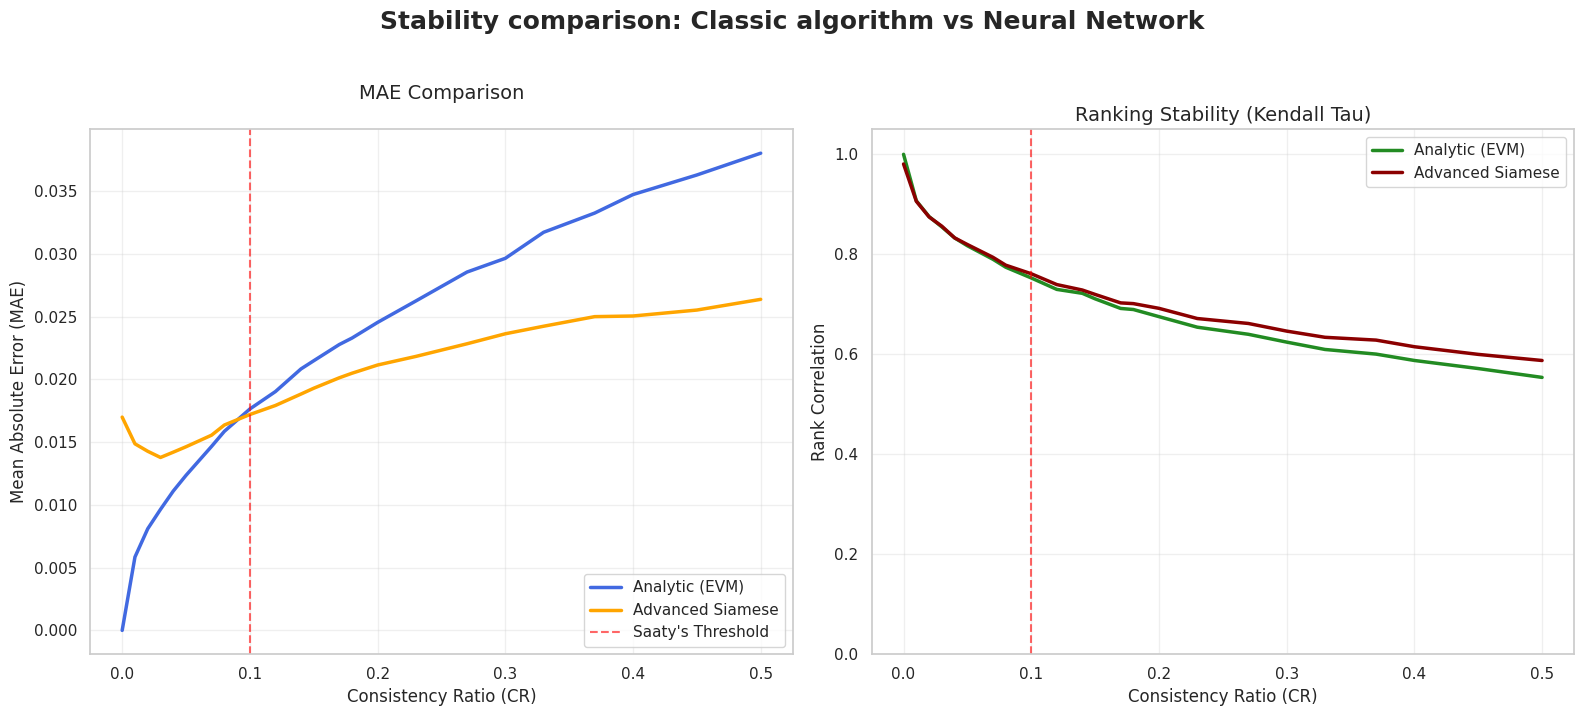

In [23]:
evm_solver = EVM()
evaluator = Evaluator()
nn_name = f"{MODEL_NAME.split('_')[0]} {MODEL_TYPE}".title()

compare_results_batch(evm_solver, evaluator, matrices, weights, predicted_priority_weights, nn_name)